## Train A Test A

### Classification

Category distribution:
0    7201
6    6463
1    5280
3    3344
5     231
4     110
7      37
8      31
2      30
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.31      0.37      0.34      1463
        Bulb       0.27      0.20      0.23      1080
      Button       1.00      0.67      0.80         3
 Coordinator       0.46      0.49      0.48       661
        Door       0.81      0.68      0.74        19
      Motion       0.44      0.41      0.42        41
      Socket       0.42      0.40      0.41      1268
 Temperature       0.71      0.71      0.71         7
   Vibration       0.75      0.75      0.75         4

    accuracy                           0.36      4546
   macro avg       0.57      0.52      0.54      4546
weighted avg       0.36      0.36      0.36      4546

Macro F1-Score: 0.5433


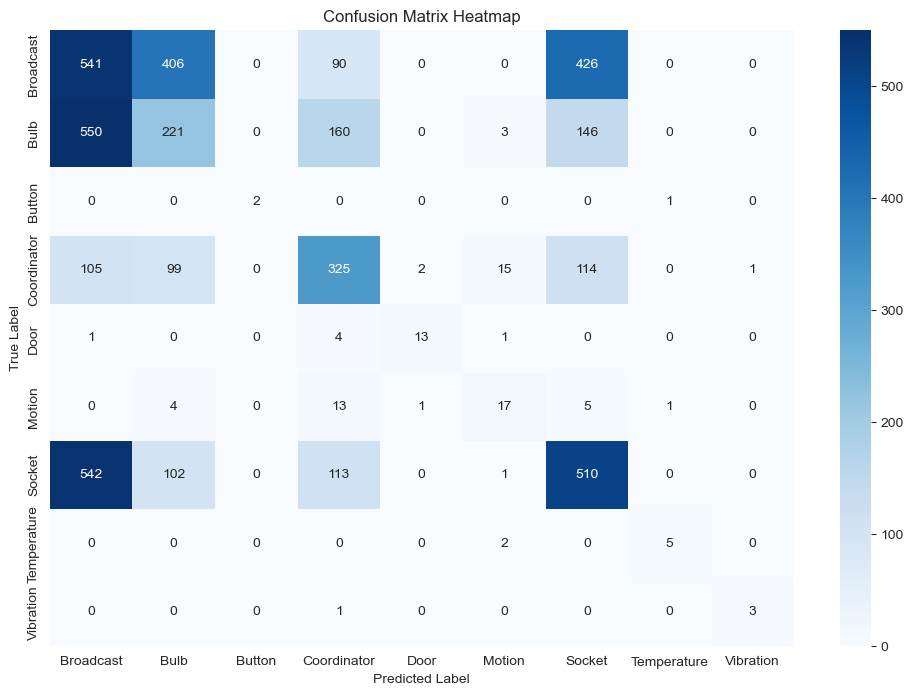

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
5     7201
6     3344
17    1769
16    1438
15    1390
7     1354
14    1177
10    1160
8     1039
11     863
9      827
12     726
13     166
1       39
22      37
2       33
4       31
0       30
3       26
21      24
18      23
20      15
19      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      0.67      0.80         3
        Aqara Door 1       0.60      0.38      0.46         8
        Aqara Door 2       0.44      0.67      0.53         6
        Aqara Motion       0.17      0.33      0.22         3
     Aqara Vibration       0.75      0.75      0.75         4
           Broadcast       0.33      0.33      0.33      1463
         Coordinator       0.43      0.56      0.48       661
       Ledvance Bulb       0.13      0.10      0.11       271
Ledvance Smart+ Plug       0.14      0.15      0.14       192
    Ledvance Z3 Plug       0.07      0.07      0.07       161
           Moes

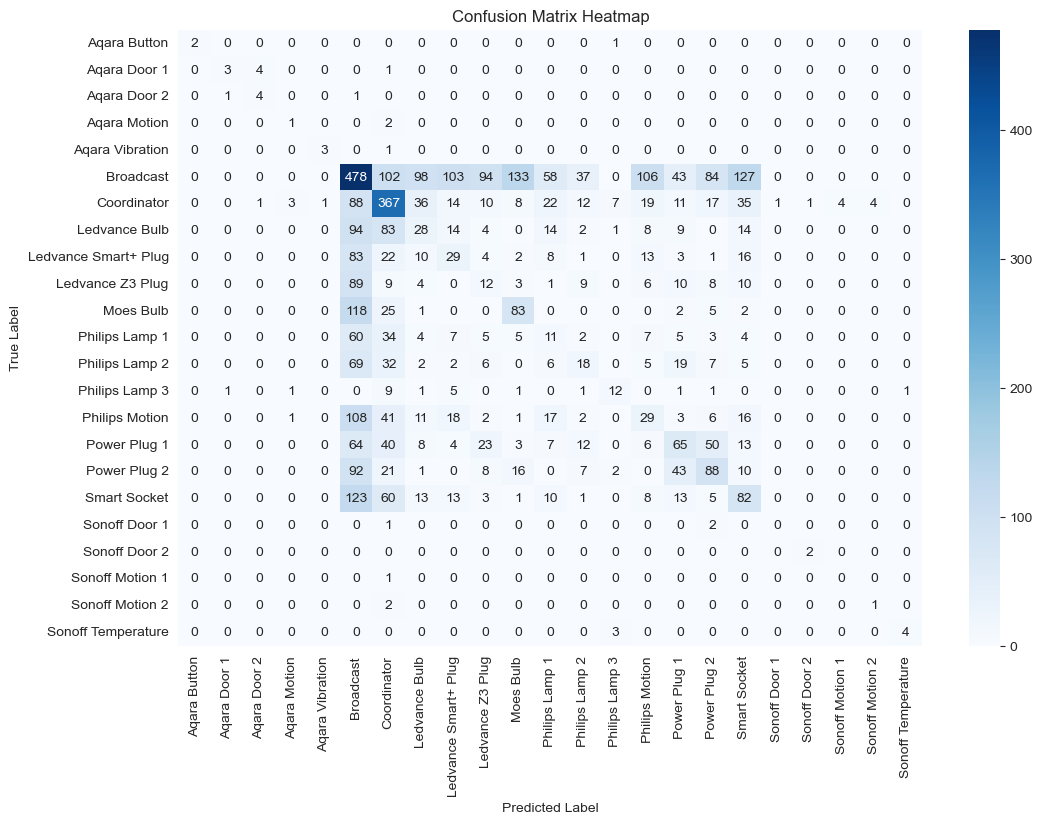

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
0    10724
6     9321
1     6740
3     5299
5      575
4      195
7      110
2       93
8       39
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.33      0.42      0.37      2102
        Bulb       0.28      0.22      0.25      1393
      Button       0.35      0.38      0.36        21
 Coordinator       0.43      0.46      0.45      1041
        Door       0.36      0.34      0.35        44
      Motion       0.55      0.57      0.56       116
      Socket       0.41      0.35      0.37      1866
 Temperature       0.30      0.23      0.26        26
   Vibration       0.20      0.09      0.12        11

    accuracy                           0.36      6620
   macro avg       0.36      0.34      0.34      6620
weighted avg       0.36      0.36      0.36      6620

Macro F1-Score: 0.3439


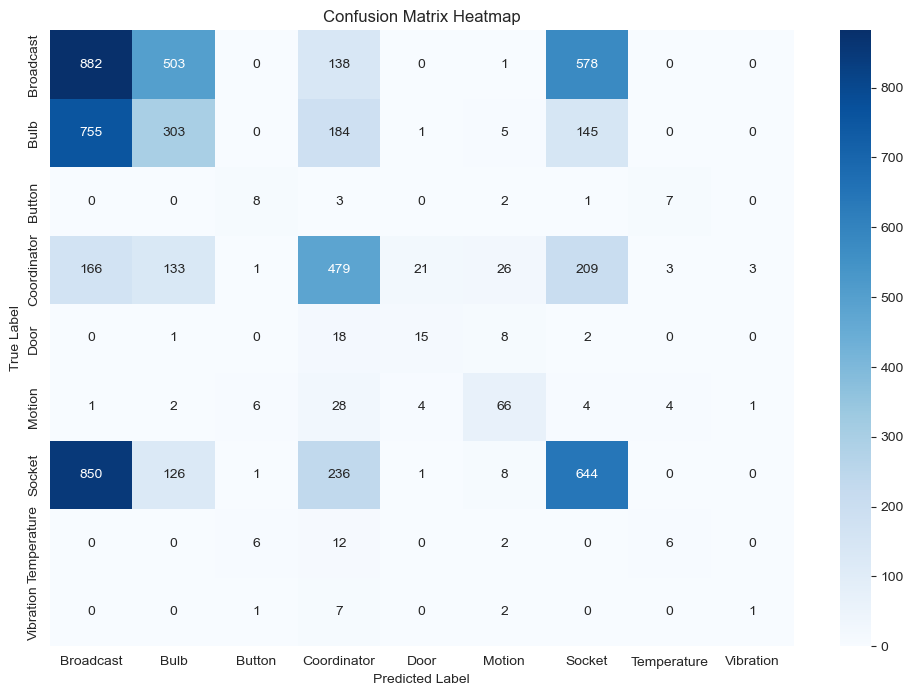

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
5     10724
6      5299
17     2811
15     2743
7      1791
10     1520
16     1519
9      1346
11     1344
13     1313
8       902
12      772
14      384
3       118
22      110
0        93
18       59
19       53
1        53
20       52
4        39
2        30
21       21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.36      0.43      0.39        21
        Aqara Door 1       0.32      0.46      0.38        13
        Aqara Door 2       0.50      0.20      0.29        10
        Aqara Motion       0.20      0.23      0.21        26
     Aqara Vibration       0.20      0.09      0.12        11
           Broadcast       0.35      0.37      0.36      2102
         Coordinator       0.41      0.51      0.46      1041
       Ledvance Bulb       0.13      0.09      0.11       387
Ledvance Smart+ Plug       0.03      0.03      0.03       190
    Ledvance Z3 Plug       0.05      0.05      0.05   

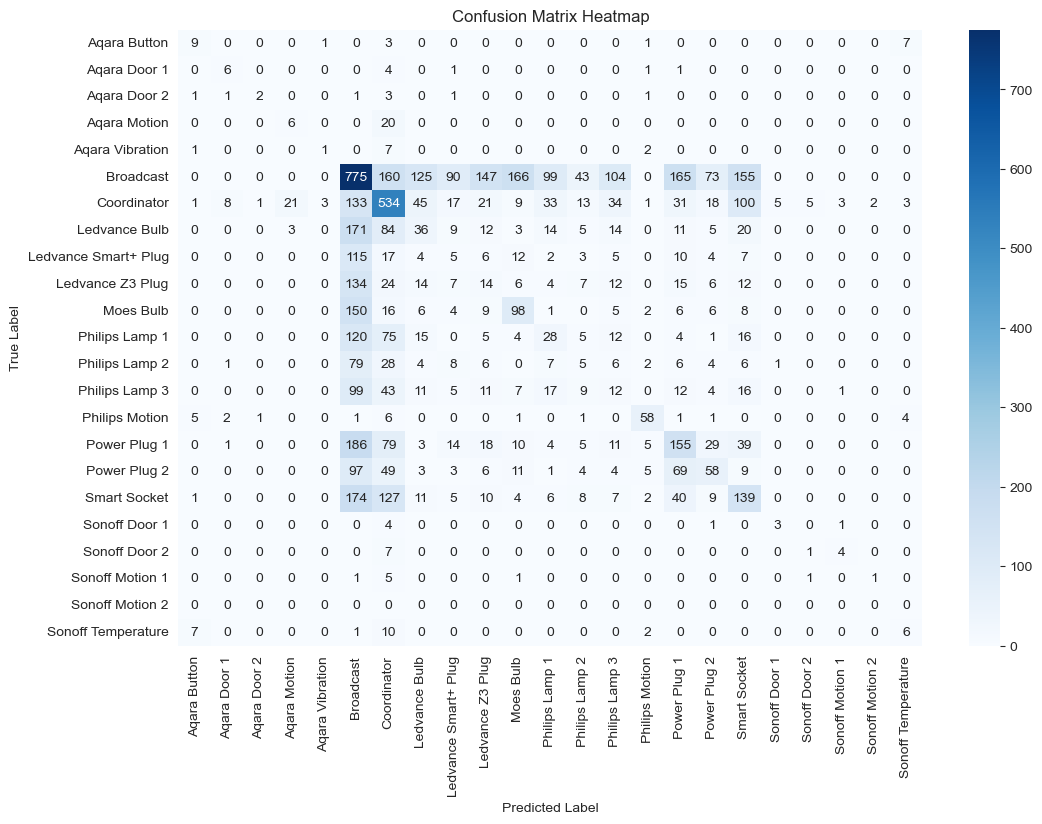

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
0    7201
6    6463
1    5280
3    3344
5     231
4     110
7      37
8      31
2      30
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.53      0.67      0.60     10724
        Bulb       0.36      0.25      0.29      6740
      Button       0.25      0.25      0.25        93
 Coordinator       0.50      0.56      0.53      5299
        Door       0.17      0.18      0.18       195
      Motion       0.48      0.41      0.44       575
      Socket       0.49      0.43      0.46      9321
 Temperature       0.17      0.08      0.11       110
   Vibration       0.00      0.00      0.00        39

    accuracy                           0.49     33096
   macro avg       0.33      0.31      0.32     33096
weighted avg       0.48      0.49      0.48     33096

Macro F1-Score: 0.3176


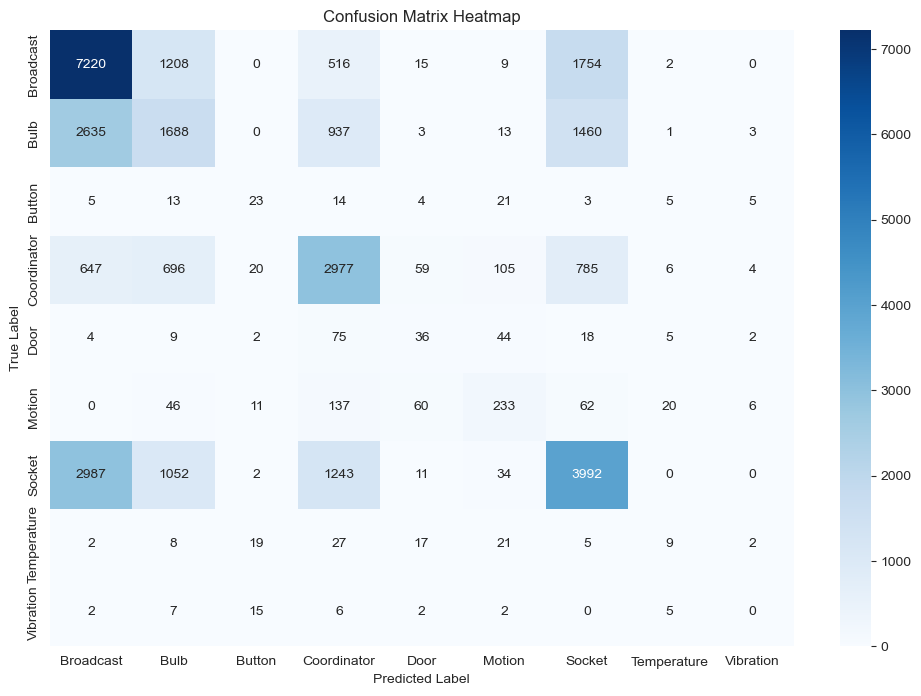

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
5     7201
6     3344
17    1769
16    1438
15    1390
7     1354
14    1177
10    1160
8     1039
11     863
9      827
12     726
13     166
1       39
22      37
2       33
4       31
0       30
3       26
21      24
18      23
20      15
19      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.25      0.24      0.24        93
        Aqara Door 1       0.12      0.09      0.11        53
        Aqara Door 2       0.00      0.00      0.00        30
        Aqara Motion       0.43      0.28      0.34       118
     Aqara Vibration       0.00      0.00      0.00        39
           Broadcast       0.69      0.38      0.49     10724
         Coordinator       0.47      0.64      0.54      5299
       Ledvance Bulb       0.14      0.13      0.14      1791
Ledvance Smart+ Plug       0.03      0.05      0.04       902
    Ledvance Z3 Plug       0.08      0.14      0.11      1346
           Moes

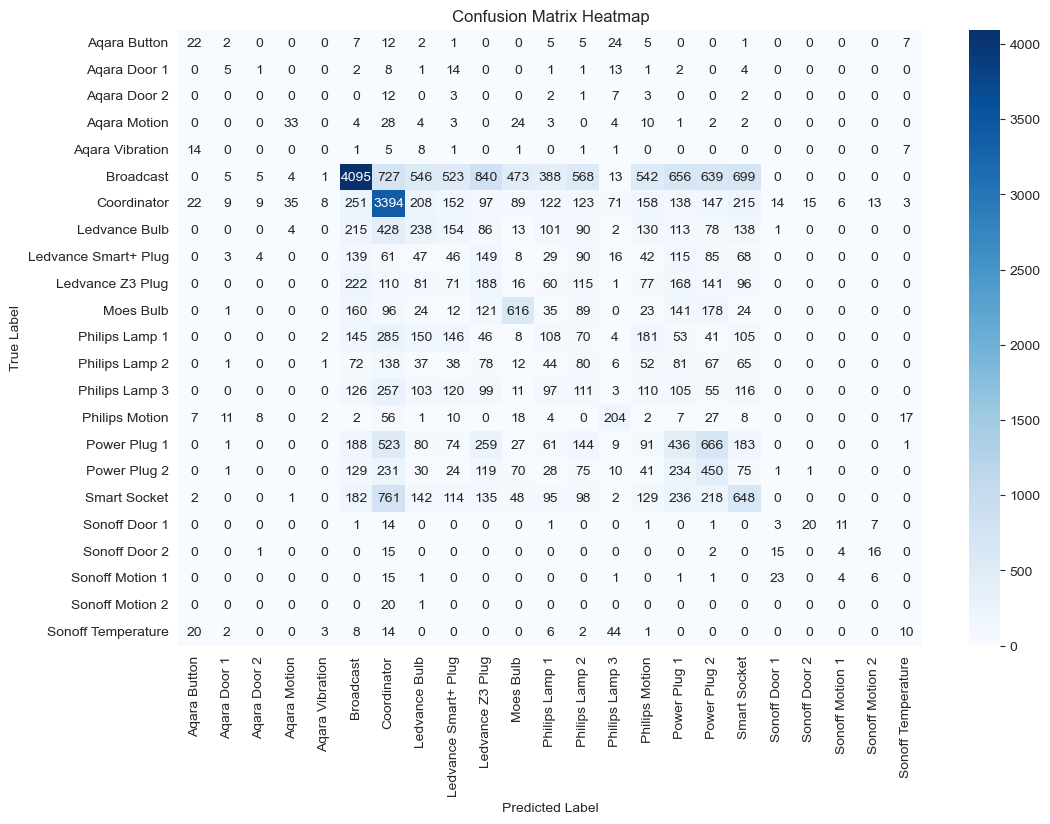

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
0    10724
6     9321
1     6740
3     5299
5      575
4      195
7      110
2       93
8       39
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.50      0.75      0.60      7201
        Bulb       0.39      0.31      0.34      5280
      Button       0.41      0.40      0.41        30
 Coordinator       0.54      0.52      0.53      3344
        Door       0.13      0.13      0.13       110
      Motion       0.33      0.42      0.37       231
      Socket       0.58      0.38      0.46      6463
 Temperature       0.24      0.14      0.17        37
   Vibration       0.00      0.00      0.00        31

    accuracy                           0.50     22727
   macro avg       0.35      0.34      0.33     22727
weighted avg       0.50      0.50      0.48     22727

Macro F1-Score: 0.3345


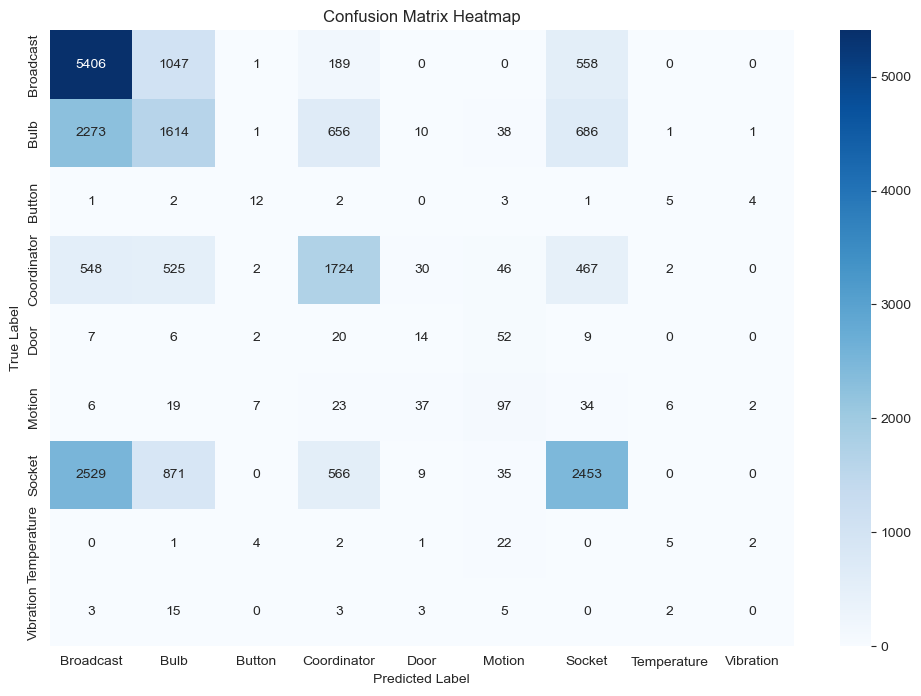

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
5     10724
6      5299
17     2811
15     2743
7      1791
10     1520
16     1519
9      1346
11     1344
13     1313
8       902
12      772
14      384
3       118
22      110
0        93
18       59
19       53
1        53
20       52
4        39
2        30
21       21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.36      0.40      0.38        30
        Aqara Door 1       0.19      0.13      0.15        39
        Aqara Door 2       0.08      0.03      0.04        33
        Aqara Motion       0.55      0.62      0.58        26
     Aqara Vibration       0.00      0.00      0.00        31
           Broadcast       0.63      0.45      0.52      7201
         Coordinator       0.45      0.65      0.53      3344
       Ledvance Bulb       0.15      0.17      0.16      1354
Ledvance Smart+ Plug       0.06      0.03      0.04      1039
    Ledvance Z3 Plug       0.09      0.10      0.09   

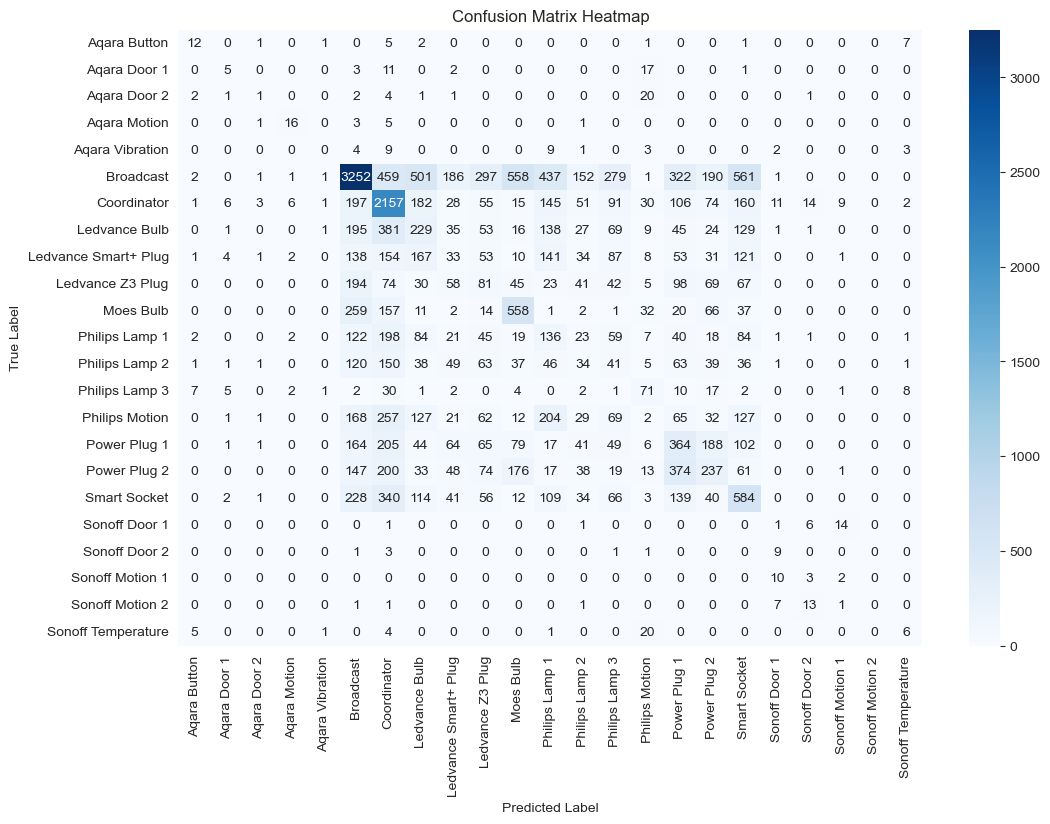

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
